# Problem 3 Example: Simpson's Reversal in Single-Cell RNA-seq Data

This notebook demonstrates how to search for **Simpson's Reversal** in a real single-cell RNA-seq
dataset obtained from the [CellxGene portal](https://cellxgene.cziscience.com/datasets).

**Simpson's Reversal** occurs when the correlation between two genes computed across *all* cells
has a different sign (or qualitatively different character) from the correlations computed
*within individual cell types* separately.

### What this notebook does
1. Downloads a small blood-cell dataset directly from the [CellxGene Census](https://chanzuckerberg.github.io/cellxgene-census/)
2. Preprocesses the data (library-size normalisation + log transform)
3. Computes overall and within-cell-type Pearson correlations across highly variable gene pairs
4. Identifies pairs that exhibit Simpson's Reversal
5. Produces scatter plots illustrating the effect

Use this as a starting template for your own analysis with a **different dataset of your choice**.
See the **Your Turn** section at the bottom.

> **Tip:** You are encouraged to use an LLM (Claude, ChatGPT, Gemini, etc.) to help understand
> or modify the code. If you do, note briefly how you used it in your write-up.

In [1]:
# Install required packages (run once; takes ~1 minute in Colab)
!pip install cellxgene-census anndata scanpy scipy matplotlib seaborn -q

In [2]:
import cellxgene_census
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

print('Imports successful.')

Imports successful.


## Step 1 — Find a small dataset in the CellxGene Census

The [CellxGene Census](https://chanzuckerberg.github.io/cellxgene-census/) aggregates hundreds of
single-cell datasets with standardised cell-type annotations. We query it for normal blood cells,
then automatically pick the smallest dataset that has at least four distinct cell types.
This keeps download time short (roughly 1–2 minutes).

In [3]:
print('Connecting to CellxGene Census (stable version)...')

# Build filter string: normal blood cells, one representative cell per donor
obs_filter = "tissue_general == 'blood' and is_primary_data == True and disease == 'normal'"

with cellxgene_census.open_soma(census_version='stable') as census:
    obs_df = census['census_data']['homo_sapiens'].obs.read(
        value_filter=obs_filter,
        column_names=['soma_joinid', 'dataset_id', 'cell_type']
    ).concat().to_pandas()

n_datasets = obs_df['dataset_id'].nunique()
print(f'Found {len(obs_df):,} normal blood cells across {n_datasets} datasets.')

# Summarise each dataset: number of cells and number of annotated cell types
stats = (
    obs_df
    .groupby('dataset_id')
    .agg(n_cells=('soma_joinid', 'count'), n_types=('cell_type', 'nunique'))
    .reset_index()
)

# Pick the smallest dataset with 500-2500 cells and at least 4 cell types
candidates = stats[
    (stats['n_cells'] >= 500) &
    (stats['n_cells'] <= 2500) &
    (stats['n_types'] >= 4)
].sort_values('n_cells')

if len(candidates) == 0:
    # Widen search if nothing matches the strict criteria
    candidates = stats[stats['n_types'] >= 3].sort_values('n_cells')

chosen_id     = candidates.iloc[0]['dataset_id']
n_chosen      = int(candidates.iloc[0]['n_cells'])
n_types_chosen = int(candidates.iloc[0]['n_types'])
chosen_joinids = obs_df[obs_df['dataset_id'] == chosen_id]['soma_joinid'].values

print(f'\nSelected dataset : {chosen_id}')
print(f'  Cells          : {n_chosen}')
print(f'  Cell types     : {n_types_chosen}')

Connecting to CellxGene Census (stable version)...


The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Found 13,822,662 normal blood cells across 64 datasets.



Selected dataset : e04daea4-4412-45b5-989e-76a9be070a89
  Cells          : 752
  Cell types     : 10


## Step 2 — Download the expression matrix

The data are returned as an [AnnData](https://anndata.readthedocs.io/) object:
- `adata.X`   — cell × gene count matrix (sparse)
- `adata.obs` — cell metadata (cell type, donor, assay, …)
- `adata.var` — gene metadata (gene name, Ensembl ID, …)

In [4]:
print(f'Downloading {len(chosen_joinids)} cells (may take 1-2 minutes)...')

with cellxgene_census.open_soma(census_version='stable') as census:
    adata = cellxgene_census.get_anndata(
        census,
        organism='homo_sapiens',
        obs_coords=chosen_joinids,
    )

# By default var_names are soma_joinid integers; replace with human-readable gene symbols
adata.var_names = adata.var['feature_name'].values
adata.var_names_make_unique()

print(f'\nDownloaded: {adata.n_obs} cells  x  {adata.n_vars} genes')
print('\nCell-type distribution:')
ct_counts = adata.obs['cell_type'].value_counts()
print(ct_counts[ct_counts > 0].to_string())

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.



Downloaded: 752 cells  x  61497 genes

Cell-type distribution:
cell_type
natural killer cell                                     137
B cell                                                  113
effector memory CD4-positive, alpha-beta T cell         113
naive thymus-derived CD4-positive, alpha-beta T cell    112
naive thymus-derived CD8-positive, alpha-beta T cell     98
classical monocyte                                       89
effector memory CD8-positive, alpha-beta T cell          59
non-classical monocyte                                   16
neutrophil                                               11
plasmacytoid dendritic cell, human                        4


## Step 3 — Preprocess the data

Standard single-cell preprocessing pipeline:

1. **Filter sparse genes** — remove genes expressed in fewer than 5% of cells.
2. **Library-size normalisation** — divide each cell's counts by its total count, then scale to
   10,000. This is the diagonal-matrix operation $D G$ from Problem 2 (part d), scaled by $10^4$.
3. **Log-transform** — apply $\log(x+1)$ to reduce the influence of very highly expressed genes.
4. **Select highly variable genes** — keep the 200 genes whose expression varies most across cells;
   these are the most informative for distinguishing cell types.

In [5]:
sc.pp.filter_genes(adata, min_cells=int(0.05 * adata.n_obs))
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=200, flavor='seurat')
adata = adata[:, adata.var['highly_variable']].copy()

print(f'After preprocessing: {adata.n_obs} cells  x  {adata.n_vars} highly variable genes')

After preprocessing: 752 cells  x  200 highly variable genes


## Step 4 — Compute overall and within-cell-type Pearson correlations

For every pair of genes we compute:
- **Overall correlation** — treats all cells the same, ignoring cell-type labels (analogous to bulk RNA-seq).
- **Within-cell-type correlation** — computed separately within each annotated cell type.

In [6]:
# Convert sparse matrix to a dense pandas DataFrame
X_dense = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
expr = pd.DataFrame(X_dense, index=adata.obs_names, columns=adata.var_names)
expr['cell_type'] = adata.obs['cell_type'].values

gene_cols  = adata.var_names.tolist()
cell_types = expr['cell_type'].unique()

# (a) Overall Pearson correlation matrix — ignores cell-type labels
overall_corr = expr[gene_cols].corr()

# (b) Within-cell-type Pearson correlation matrices
#     Only compute for cell types with at least 30 cells (for a stable estimate)
within_corr = {}
for ct in cell_types:
    sub = expr[expr['cell_type'] == ct][gene_cols]
    if len(sub) >= 30:
        within_corr[ct] = sub.corr()

print('Cell types included in within-type analysis (>=30 cells):')
for ct in within_corr:
    n = int((expr['cell_type'] == ct).sum())
    print(f'  {ct}: {n} cells')

Cell types included in within-type analysis (>=30 cells):
  naive thymus-derived CD4-positive, alpha-beta T cell: 112 cells
  effector memory CD4-positive, alpha-beta T cell: 113 cells
  effector memory CD8-positive, alpha-beta T cell: 59 cells
  naive thymus-derived CD8-positive, alpha-beta T cell: 98 cells
  natural killer cell: 137 cells
  B cell: 113 cells
  classical monocyte: 89 cells


## Step 5 — Search for Simpson's Reversal

A gene pair $(g_1, g_2)$ shows **Simpson's Reversal** if the sign of the overall Pearson
correlation differs from the within-cell-type correlations in at least half of the cell types.

We restrict attention to pairs with a non-trivial overall correlation ($|r| \geq 0.15$).

In [7]:
reversal_examples = []

for i, g1 in enumerate(gene_cols):
    for g2 in gene_cols[i + 1:]:
        r_all = overall_corr.loc[g1, g2]
        if np.isnan(r_all) or abs(r_all) < 0.15:
            continue

        within_rs = [
            within_corr[ct].loc[g1, g2]
            for ct in within_corr
            if not np.isnan(within_corr[ct].loc[g1, g2])
        ]
        if len(within_rs) < 2:
            continue

        n_reversed = sum(1 for r in within_rs if np.sign(r) != np.sign(r_all))

        # Reversal: overall sign differs from within-type sign in >= half the cell types
        if n_reversed >= len(within_rs) / 2:
            reversal_examples.append({
                'gene1'           : g1,
                'gene2'           : g2,
                'r_overall'       : round(r_all, 4),
                'r_within_mean'   : round(float(np.mean(within_rs)), 4),
                'n_types_reversed': n_reversed,
                'n_types_total'   : len(within_rs),
            })

reversal_df = (
    pd.DataFrame(reversal_examples)
    .sort_values('r_overall', key=abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Gene pairs showing Simpson's Reversal: {len(reversal_df)}")
if len(reversal_df) > 0:
    print('\nTop examples (sorted by |r_overall|):')
    print(reversal_df.head(10).to_string(index=False))
else:
    print('No pairs found at |r_overall| >= 0.15. Try lowering the threshold to 0.1.')

Gene pairs showing Simpson's Reversal: 2829

Top examples (sorted by |r_overall|):
  gene1   gene2  r_overall  r_within_mean  n_types_reversed  n_types_total
  CSF3R  S100A8     0.8957         0.2732                 2              4
 S100A8 SLC11A1     0.8436         0.2862                 2              4
  CSF3R SLC11A1     0.8319         0.1989                 3              5
    LYZ TNFAIP2     0.8161         0.0524                 1              2
 S100A9     LYZ     0.7590         0.0594                 2              3
SLC11A1 TNFAIP2     0.7525         0.3040                 2              3
SLC11A1     LYZ     0.7499         0.0689                 2              3
   NCF2 TNFAIP2     0.7455         0.0084                 2              3
   NCF2 SLC11A1     0.7450         0.0412                 4              5
 S100A8    NCF2     0.7379         0.0656                 2              3


## Step 6 — Visualise the top example

Two scatter plots side by side:
- **Left** — all cells plotted together (the "bulk" view).
- **Right** — the same cells coloured by annotated cell type.

Plotting top reversal pair: CSF3R  vs  S100A8


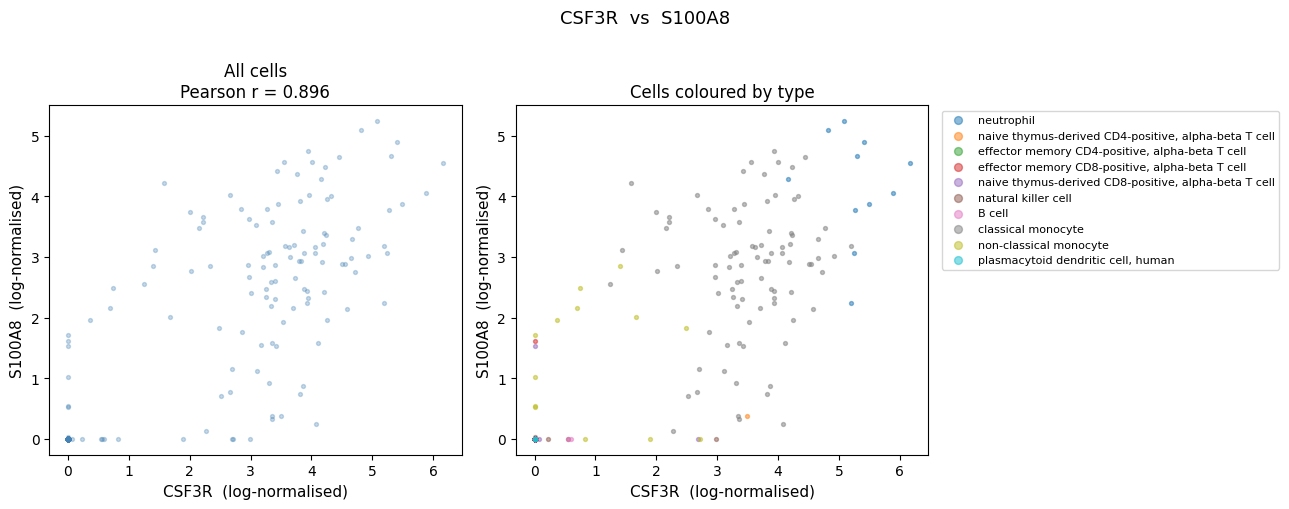


Overall Pearson r = 0.8957

Within-cell-type Pearson r:
  B cell                                         r = +nan  (n = 113)
  classical monocyte                             r = +0.1124  (n = 89)
  effector memory CD4-positive, alpha-beta T cell  r = +nan  (n = 113)
  effector memory CD8-positive, alpha-beta T cell  r = +nan  (n = 59)
  naive thymus-derived CD4-positive, alpha-beta T cell  r = +1.0000  (n = 112)
  naive thymus-derived CD8-positive, alpha-beta T cell  r = -0.0106  (n = 98)
  natural killer cell                            r = -0.0091  (n = 137)


In [8]:
if len(reversal_df) > 0:
    g1 = reversal_df.iloc[0]['gene1']
    g2 = reversal_df.iloc[0]['gene2']
    print(f"Plotting top reversal pair: {g1}  vs  {g2}")
else:
    # Fallback: show most correlated pair (no reversal)
    upper = overall_corr.where(
        np.triu(np.ones(overall_corr.shape), k=1).astype(bool)
    )
    g1, g2 = upper.stack().abs().idxmax()
    print(f'No reversal found. Showing most correlated pair instead: {g1}  vs  {g2}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: all cells, no grouping ---
r_all, _ = pearsonr(expr[g1], expr[g2])
axes[0].scatter(expr[g1], expr[g2],
                alpha=0.3, s=8, color='steelblue', rasterized=True)
axes[0].set_xlabel(f'{g1}  (log-normalised)', fontsize=11)
axes[0].set_ylabel(f'{g2}  (log-normalised)', fontsize=11)
axes[0].set_title(f'All cells\nPearson r = {r_all:.3f}', fontsize=12)

# --- Right panel: cells coloured by cell type ---
palette   = sns.color_palette('tab10', n_colors=len(cell_types))
color_map = dict(zip(cell_types, palette))
for ct in cell_types:
    mask = expr['cell_type'] == ct
    axes[1].scatter(
        expr.loc[mask, g1], expr.loc[mask, g2],
        alpha=0.5, s=8, color=color_map[ct], label=ct, rasterized=True
    )
axes[1].set_xlabel(f'{g1}  (log-normalised)', fontsize=11)
axes[1].set_ylabel(f'{g2}  (log-normalised)', fontsize=11)
axes[1].set_title('Cells coloured by type', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, markerscale=2)

plt.suptitle(f'{g1}  vs  {g2}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('simpsons_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOverall Pearson r = {r_all:.4f}')
print('\nWithin-cell-type Pearson r:')
for ct in sorted(within_corr.keys()):
    r_ct = within_corr[ct].loc[g1, g2]
    n_ct = int((expr['cell_type'] == ct).sum())
    print(f'  {ct:45s}  r = {r_ct:+.4f}  (n = {n_ct})')

---
## Your Turn

The example above ran on a dataset chosen automatically. For your submission, **pick a different
dataset of your choice** from the CellxGene portal.

### Finding and loading your dataset

Browse the [CellxGene datasets page](https://cellxgene.cziscience.com/datasets) and filter by
tissue, disease, organism, or cell type. Select any dataset with multiple annotated cell types
and at least a few hundred cells.

**Option A — Census API (no file download needed):**  
Find the `dataset_id` of your chosen dataset (visible in the dataset detail page URL or metadata
panel on the portal). Then replace the filter in Step 1 with:
```python
obs_filter = "dataset_id == 'YOUR_DATASET_ID_HERE' and is_primary_data == True"
```

**Option B — Direct H5AD download:**  
Click the *Download* button on the dataset detail page to get an `.h5ad` file,
then load it with:
```python
adata = sc.read_h5ad('path/to/your_file.h5ad')
```

### What to submit

Include in your write-up:
1. **Dataset**: title, organism, tissue, total cell count, and number of annotated cell types.
2. **Gene pair**: the two genes you examined and why you chose them (or how you searched).
3. **Overall correlation**: scatter plot (all cells) and Pearson *r* value.
4. **Within-cell-type correlations**: coloured scatter plot and per-cell-type *r* values.
5. **Conclusion**: is Simpson's Reversal present? What does this tell you biologically?

If you do not find a reversal with your first gene pair, try other pairs and describe your search.

### Using an LLM

You are encouraged to use an LLM (Claude, ChatGPT, Gemini, etc.) to help understand or modify the code,
interpret results, or explore the biology. If you do, briefly note how you used it in your write-up.